In [1]:
!pip install fredapi us pygris

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pygris]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from fredapi import Fred
import calendar
import us
from pygris import states
from pygris.utils import shift_geometry
import time

fred = Fred(api_key="")

In [3]:
# -- Get data for unemployment(TABLEAU LINE CHART)
# -- We want to get rid of last entry as that wasnt apart of our time series. We will analyze that later
unemp_college = fred.get_series('CGBD2024')
unemp_non_college_20_24 = fred.get_series('HSGS2024').to_frame("20-24_No_College")[:-1]
unemp_all = fred.get_series('UNRATE').to_frame('All')['2000':]
unemp_all = unemp_all[:-1]

In [4]:
# -- Concat
unemp_20_24_year_olds = pd.concat([unemp_college.to_frame("20-24_College_Graduates")[:-1], unemp_non_college_20_24, unemp_all], axis=1)

unemp_20_24_year_olds

,20-24_College_Graduates,20-24_No_College,All
2000-01-01,3.8,9.3,4.0
2000-02-01,4.4,9.6,4.1
2000-03-01,5.1,9.5,4.0
2000-04-01,4.0,7.5,3.8
2000-05-01,5.1,8.1,4.0
...,...,...,...
2025-04-01,4.4,9.9,4.2
2025-05-01,6.1,8.6,4.2
2025-06-01,7.3,10.0,4.1
2025-07-01,8.5,8.8,4.2


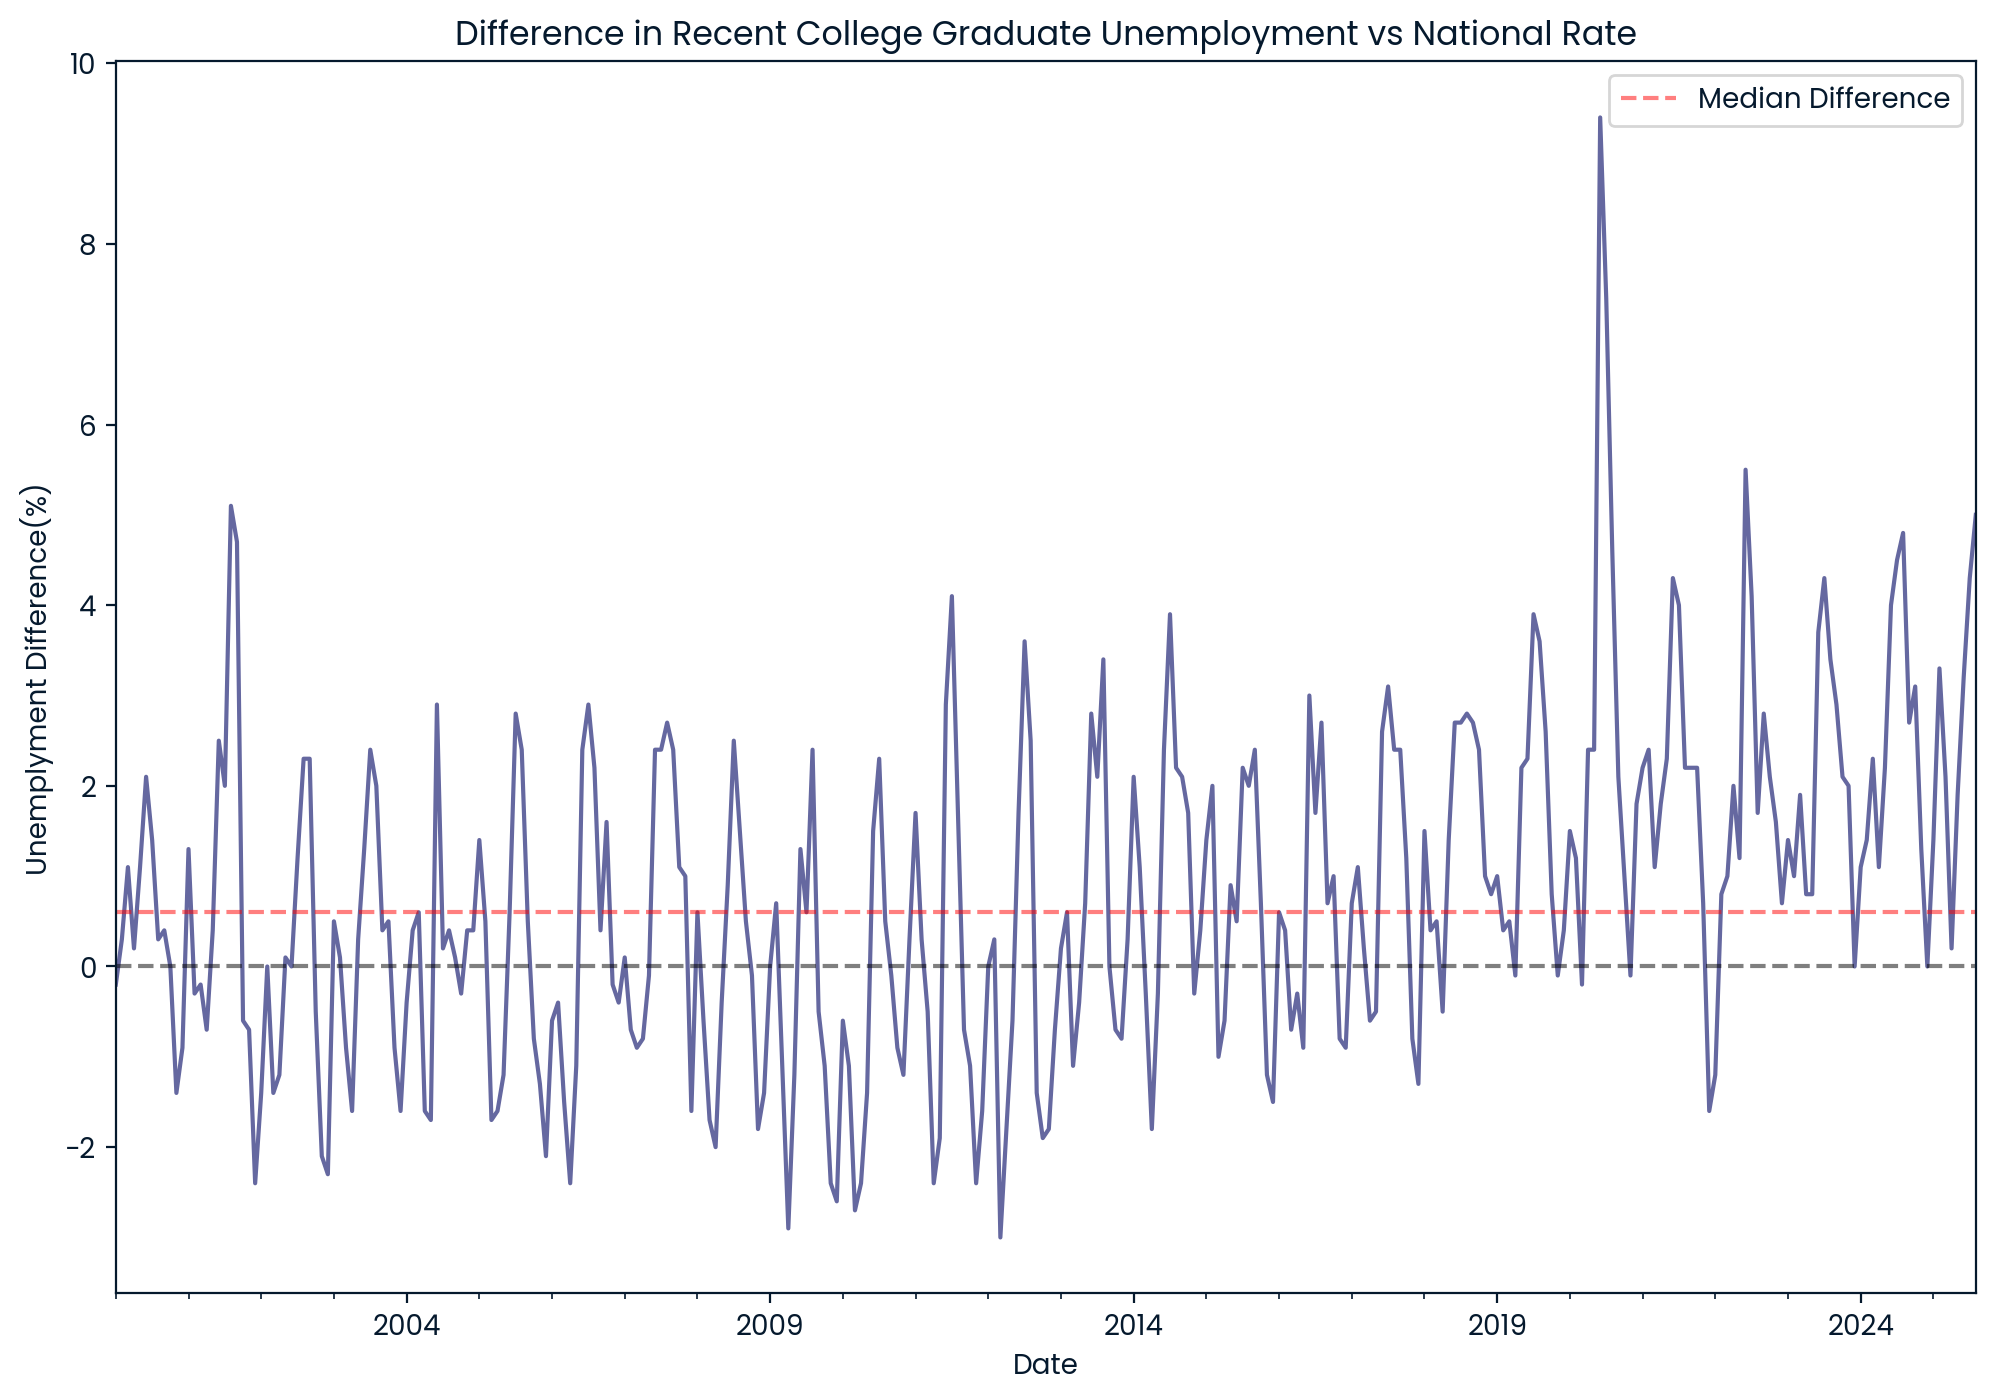

In [5]:
# -- Differences between recent grad and national rate
plt.figure(figsize=(12, 8))
(unemp_20_24_year_olds['20-24_College_Graduates'] - unemp_20_24_year_olds['All']).plot()
plt.axhline(y=0, linestyle='--', color = 'k', alpha = 0.5)
plt.axhline(y=(unemp_20_24_year_olds['20-24_College_Graduates'] - unemp_20_24_year_olds['All']).median(), linestyle='--', color = 'r', alpha = 0.5, label="Median Difference")

plt.xlabel("Date")
plt.ylabel("Unemplyment Difference(%)")
plt.title("Difference in Recent College Graduate Unemployment vs National Rate")
plt.legend()
plt.show()

In [6]:
(unemp_20_24_year_olds['20-24_College_Graduates'] - unemp_20_24_year_olds['All']).to_frame("Difference").\
        sort_values(by="Difference", ascending=False).head(5)

,Difference
2020-06-01,9.4
2020-07-01,7.4
2022-06-01,5.5
2001-08-01,5.1
2025-08-01,5.0


Now we will get data for the maps we will create in Tableau

In [7]:
# -- Get State Data
# -- Scrape unemployment by state
states = dict(zip([state.abbr for state in us.states.STATES], [state.name for state in us.states.STATES]))

# To print the first 5 items, convert the dict items to a list and slice
print(list(states.items())[:5])

[('AL', 'Alabama'), ('AK', 'Alaska'), ('AZ', 'Arizona'), ('AR', 'Arkansas'), ('CA', 'California')]


In [8]:
# # Plot map with unemployment by state(2025)
states_df_unemp = pd.DataFrame()

# stuff = list(states.items())[:3]


for key, val in states.items():
    unemp_series = fred.get_series(f"{key}UR").resample('MS').mean().to_frame("Unemployment_Rate")
    unemp_series["State"] = val

    states_df_unemp = pd.concat([states_df_unemp, unemp_series])

states_df_unemp = states_df_unemp.reset_index()
states_df_unemp.columns = ["Date"] + list(states_df_unemp.columns[1:])

In [9]:
states_df_unemp.head()

,Date,Unemployment_Rate,State
0,1976-01-01,6.7,Alabama
1,1976-02-01,6.6,Alabama
2,1976-03-01,6.6,Alabama
3,1976-04-01,6.5,Alabama
4,1976-05-01,6.4,Alabama


In [13]:
# Plot map lfpr by state
lfpr = pd.DataFrame()

for state in [state.name for state in us.states.STATES]:
    query = fred.search(f'Labor Force Participation Rate for {state}')
    print(f'Labor Force Participation Rate for {state}')
    # Fix: Use '&' for element-wise logical AND, and wrap each condition in parentheses
    query_filtered = query[
        (query.index.str.startswith('LBSS')) &
        (query.title == f'Labor Force Participation Rate for {state}')
    ]

    if not query_filtered.empty:
        temp_lfpr = fred.get_series(query_filtered.index.values[0]).resample('MS').mean().to_frame("Labor_Force_Participation_Rate")
        temp_lfpr['State'] = state
        lfpr = pd.concat([lfpr, temp_lfpr])
        time.sleep(1)
    
lfpr = lfpr.reset_index()
lfpr.columns = ["Date"] + list(lfpr.columns[1:])

Labor Force Participation Rate for Alabama
Labor Force Participation Rate for Alaska
Labor Force Participation Rate for Arizona
Labor Force Participation Rate for Arkansas
Labor Force Participation Rate for California
Labor Force Participation Rate for Colorado
Labor Force Participation Rate for Connecticut
Labor Force Participation Rate for Delaware
Labor Force Participation Rate for Florida
Labor Force Participation Rate for Georgia
Labor Force Participation Rate for Hawaii
Labor Force Participation Rate for Idaho
Labor Force Participation Rate for Illinois
Labor Force Participation Rate for Indiana
Labor Force Participation Rate for Iowa
Labor Force Participation Rate for Kansas
Labor Force Participation Rate for Kentucky
Labor Force Participation Rate for Louisiana
Labor Force Participation Rate for Maine
Labor Force Participation Rate for Maryland
Labor Force Participation Rate for Massachusetts
Labor Force Participation Rate for Michigan
Labor Force Participation Rate for Minneso

In [14]:
lfpr.head()

,Date,Labor_Force_Participation_Rate,State
0,1976-01-01,57.1,Alabama
1,1976-02-01,56.9,Alabama
2,1976-03-01,56.8,Alabama
3,1976-04-01,56.8,Alabama
4,1976-05-01,56.8,Alabama


In [19]:
# -- lastly, get minimum wage
states_wo_mnwg = ["Alabama", "Louisiana", "Mississippi", "South Carolina", "Tennessee"]
state_minwg = pd.DataFrame()

states = dict(zip([state.abbr for state in us.states.STATES], [state.name for state in us.states.STATES]))

for key, val in states.items():
    if val in states_wo_mnwg:
        continue
    
    temp_mnwg = fred.get_series(f"STTMINWG{key}")['1976':].resample('MS').mean().to_frame("State_Minimum_Wage")
    temp_mnwg["State"] = val
    state_minwg = pd.concat([state_minwg, temp_mnwg])
    
state_minwg["State_Minimum_Wage"] = state_minwg["State_Minimum_Wage"].fillna(method='ffill')
state_minwg = state_minwg.reset_index()
state_minwg.columns = ["Date"] + list(state_minwg.columns[1:])

In [20]:
state_minwg.head()

,Date,State_Minimum_Wage,State
0,1976-01-01,2.8,Alaska
1,1976-02-01,2.8,Alaska
2,1976-03-01,2.8,Alaska
3,1976-04-01,2.8,Alaska
4,1976-05-01,2.8,Alaska


In [21]:
# -- Merge Everything
state_econ_info = states_df_unemp.merge(lfpr, on=["State", 'Date'])
state_econ_info = state_econ_info.merge(state_minwg, on=["State", "Date"], how='left')

In [22]:
# Sort so filling works correctly
state_econ_info = state_econ_info.sort_values(["State", "Date"]).copy()

# Apply imputation only to states NOT in states_wo_mnwg
def impute_group(group):
    if group.name in states_wo_mnwg:
        # leave as-is
        return group
    else:
        # forward-fill then backward-fill
        group["State_Minimum_Wage"] = group["State_Minimum_Wage"].ffill().bfill()
        return group

state_econ_info = state_econ_info.groupby("State", group_keys=False).apply(impute_group)

In [23]:
state_econ_info

,Date,Unemployment_Rate,State,Labor_Force_Participation_Rate,State_Minimum_Wage
0,1976-01-01,6.7,Alabama,57.1,NaN
1,1976-02-01,6.6,Alabama,56.9,NaN
2,1976-03-01,6.6,Alabama,56.8,NaN
3,1976-04-01,6.5,Alabama,56.8,NaN
4,1976-05-01,6.4,Alabama,56.8,NaN
...,...,...,...,...,...
29795,2025-04-01,3.3,Wyoming,62.5,7.25
29796,2025-05-01,3.3,Wyoming,62.2,7.25
29797,2025-06-01,3.3,Wyoming,62.0,7.25
29798,2025-07-01,3.3,Wyoming,61.8,7.25


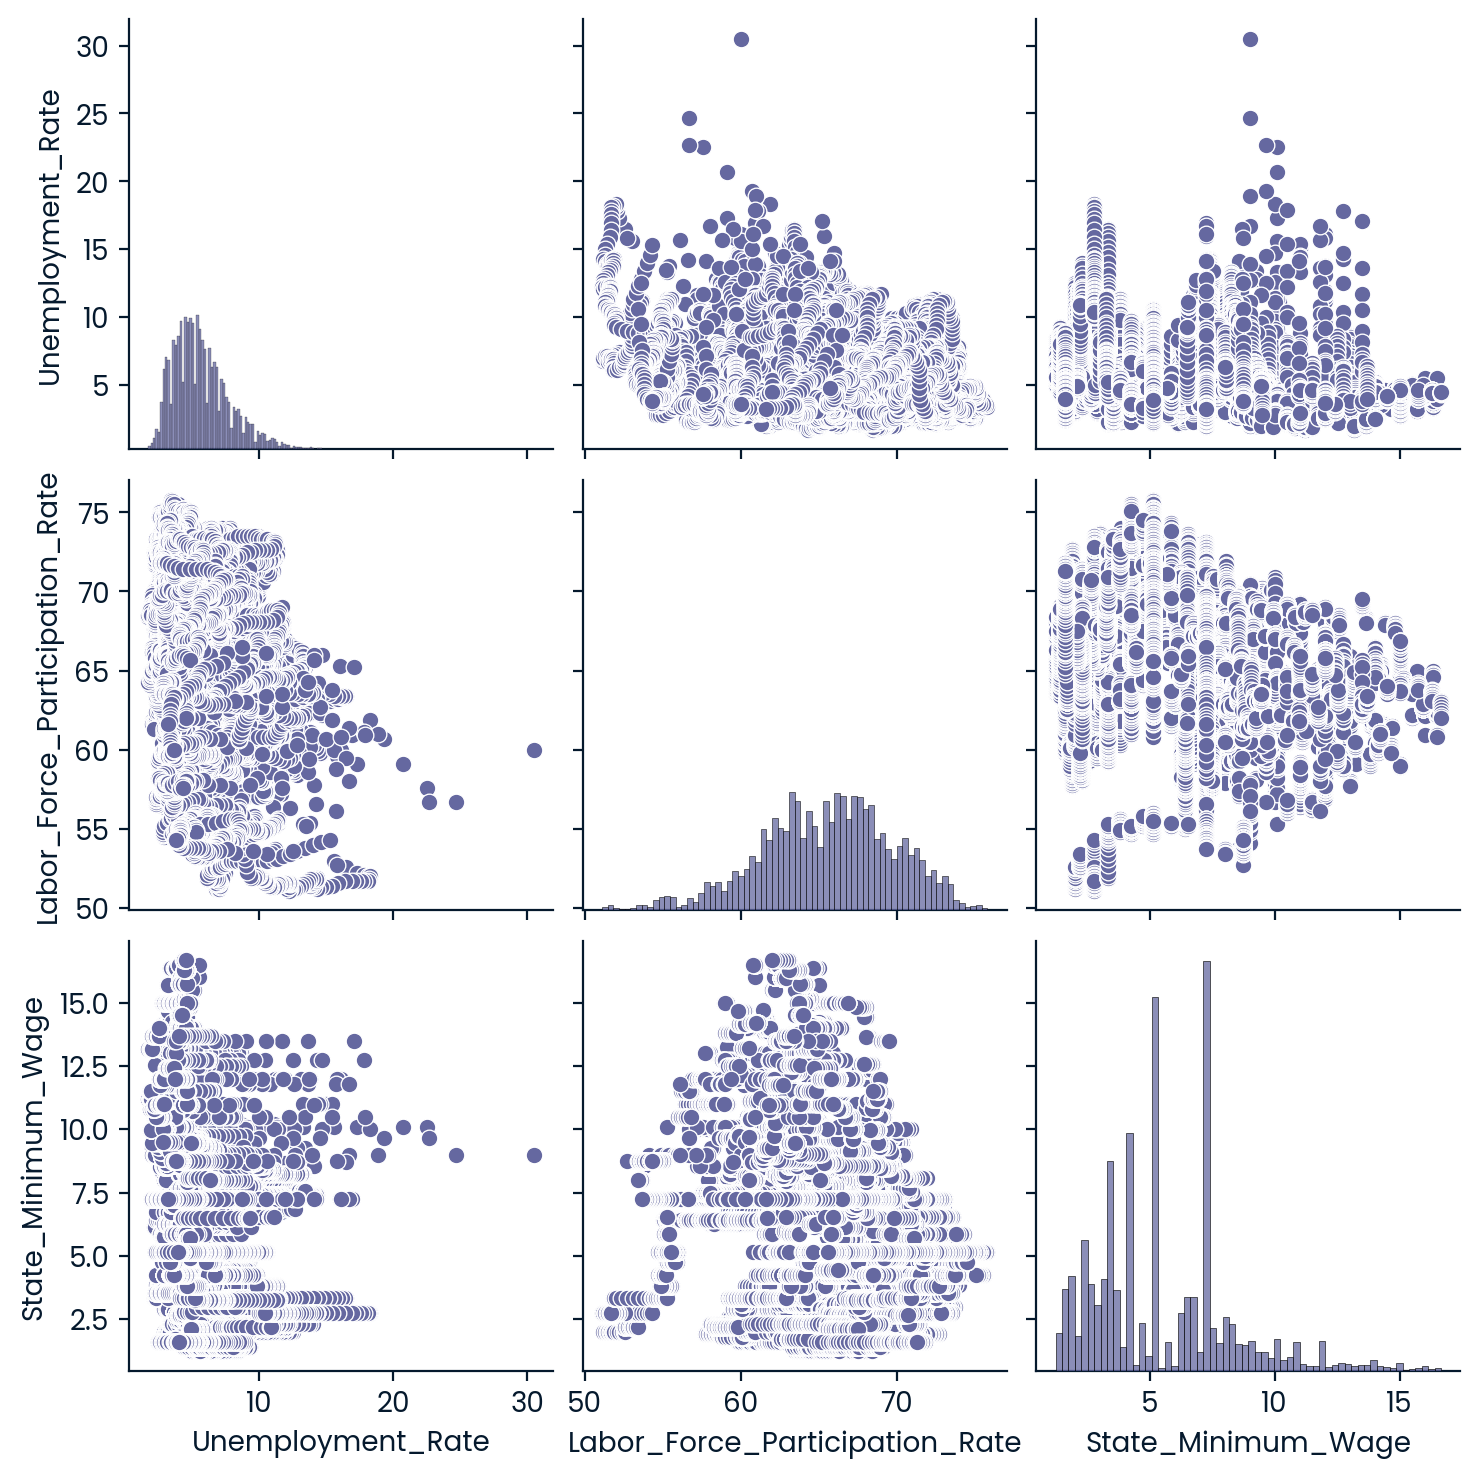

In [24]:
import seaborn as sns
sns.pairplot(state_econ_info[["Unemployment_Rate", "Labor_Force_Participation_Rate", "State_Minimum_Wage"]])

Text(0.5, 1.0, 'Correlation of Economic Indicators')

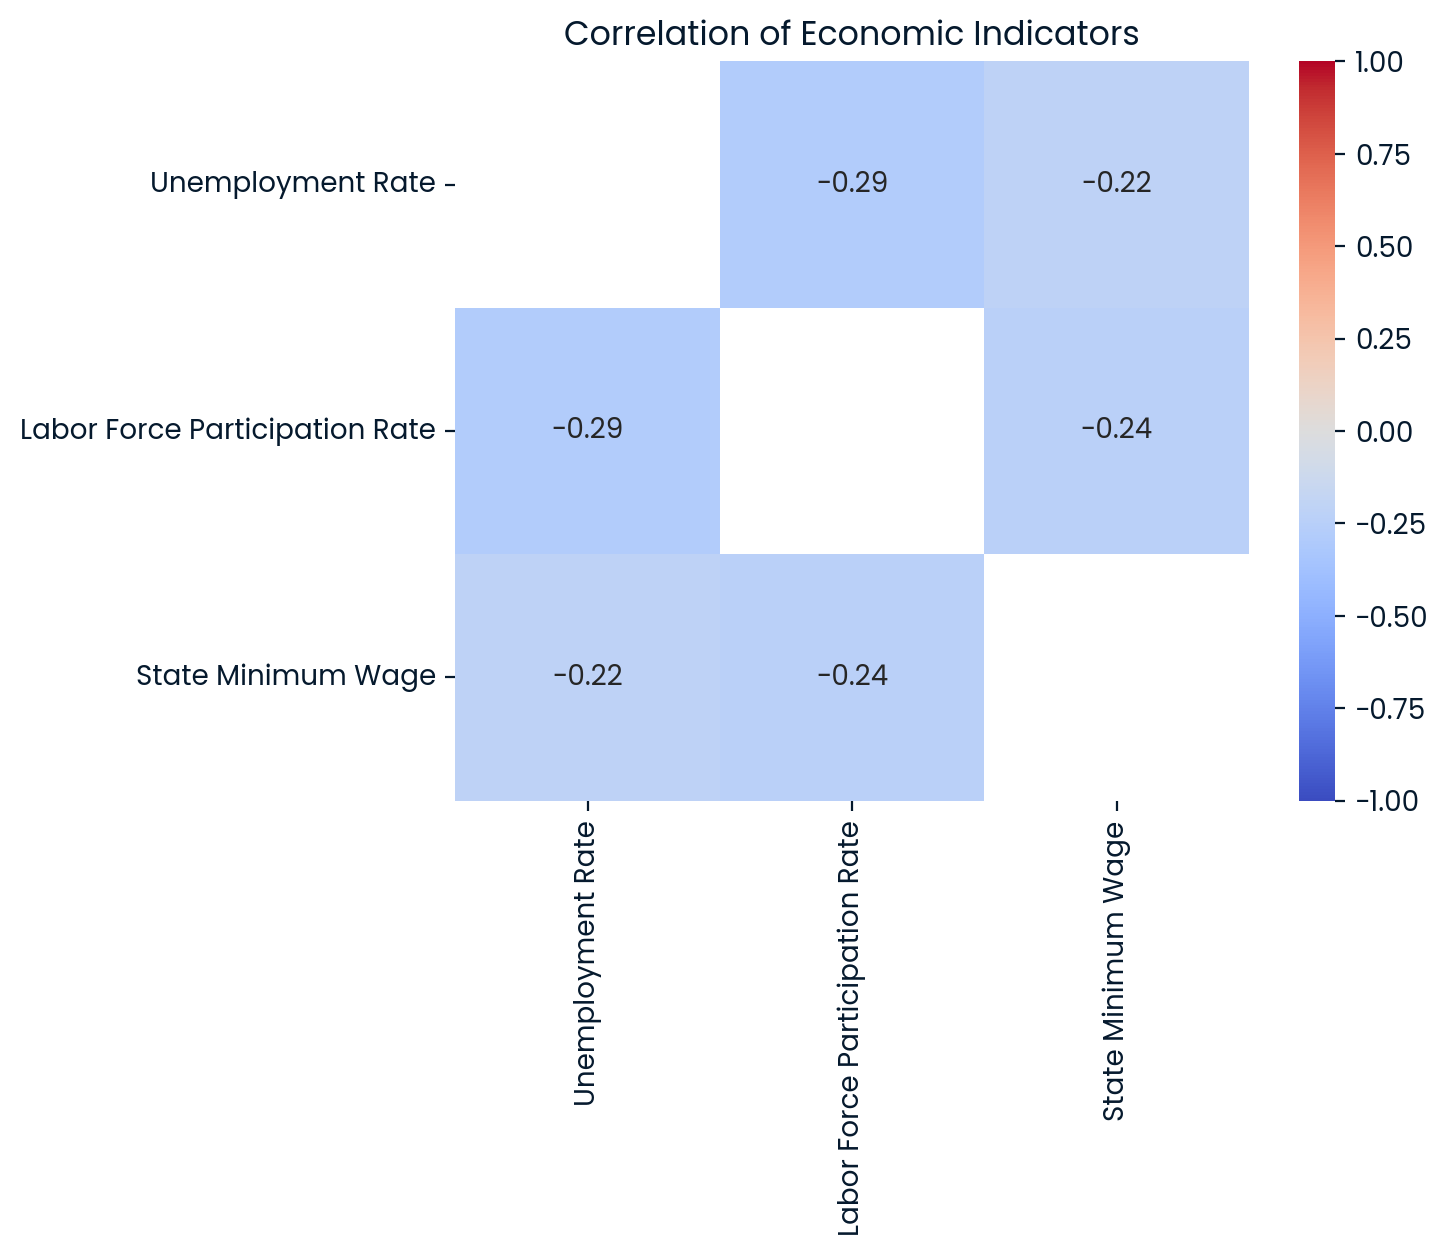

In [25]:
import numpy as np
import matplotlib.pyplot as plt

corr = state_econ_info[["Unemployment_Rate", "Labor_Force_Participation_Rate", "State_Minimum_Wage"]].dropna()

corr.columns = ["Unemployment Rate", "Labor Force Participation Rate", "State Minimum Wage"]
corr = corr.corr()

# Set diagonal to np.nan to remove self-comparisons
np.fill_diagonal(corr.values, np.nan)

sns.heatmap(corr, annot=True, mask=np.eye(corr.shape[0], dtype=bool), cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation of Economic Indicators")

Text(0.5, 1.0, 'Correlation of Economic Indicators 2024-Pres')

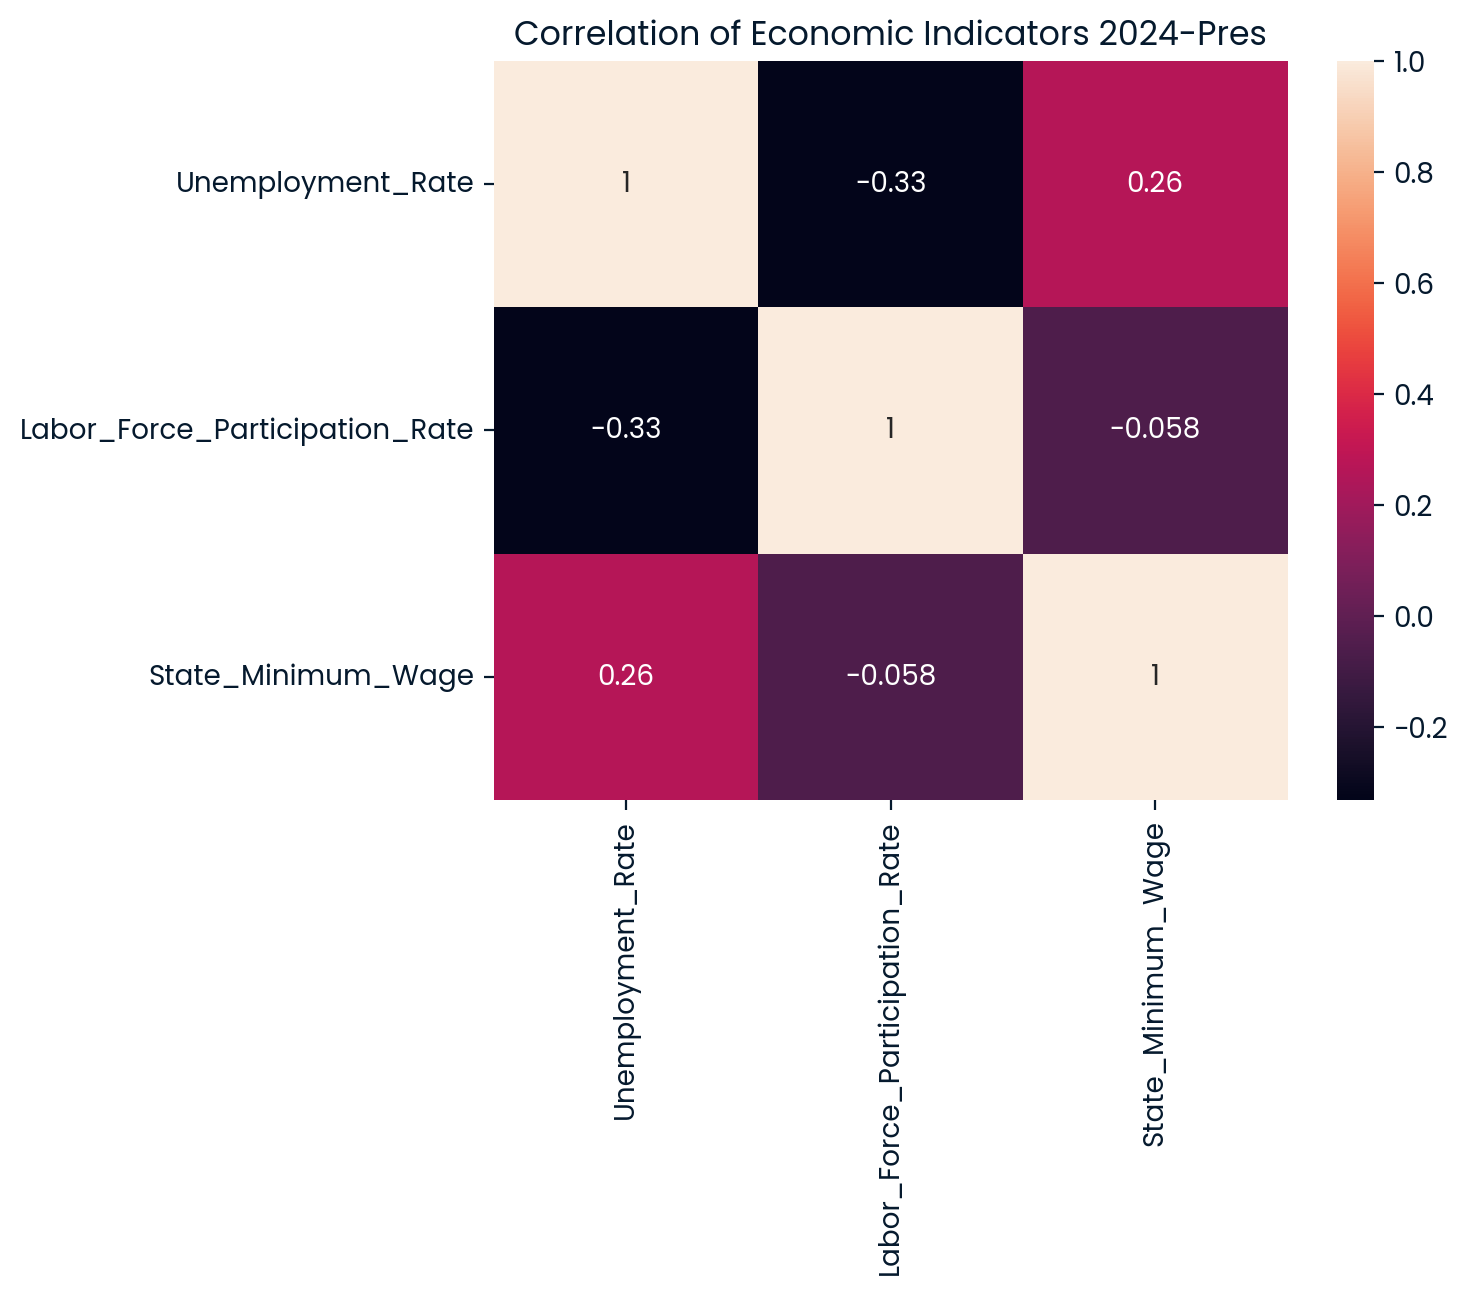

In [26]:
# -- Lets see most recent Data
new_state_data = state_econ_info[state_econ_info.Date >= pd.Timestamp('2024-01-01')]
sns.heatmap(new_state_data[["Unemployment_Rate", "Labor_Force_Participation_Rate", "State_Minimum_Wage"]].dropna().corr(), annot = True)
plt.title("Correlation of Economic Indicators 2024-Pres")

POST-HOC Analysis

In [27]:
# -- Now we will analyze unemployment for recent college grads with the new entry(September Data)
unemp_college_updated = fred.get_series('CGBD2024')
unemp_college_updated

2000-01-01    3.8
2000-02-01    4.4
2000-03-01    5.1
2000-04-01    4.0
2000-05-01    5.1
             ... 
2025-05-01    6.1
2025-06-01    7.3
2025-07-01    8.5
2025-08-01    9.3
2025-09-01    9.7
Length: 309, dtype: float64

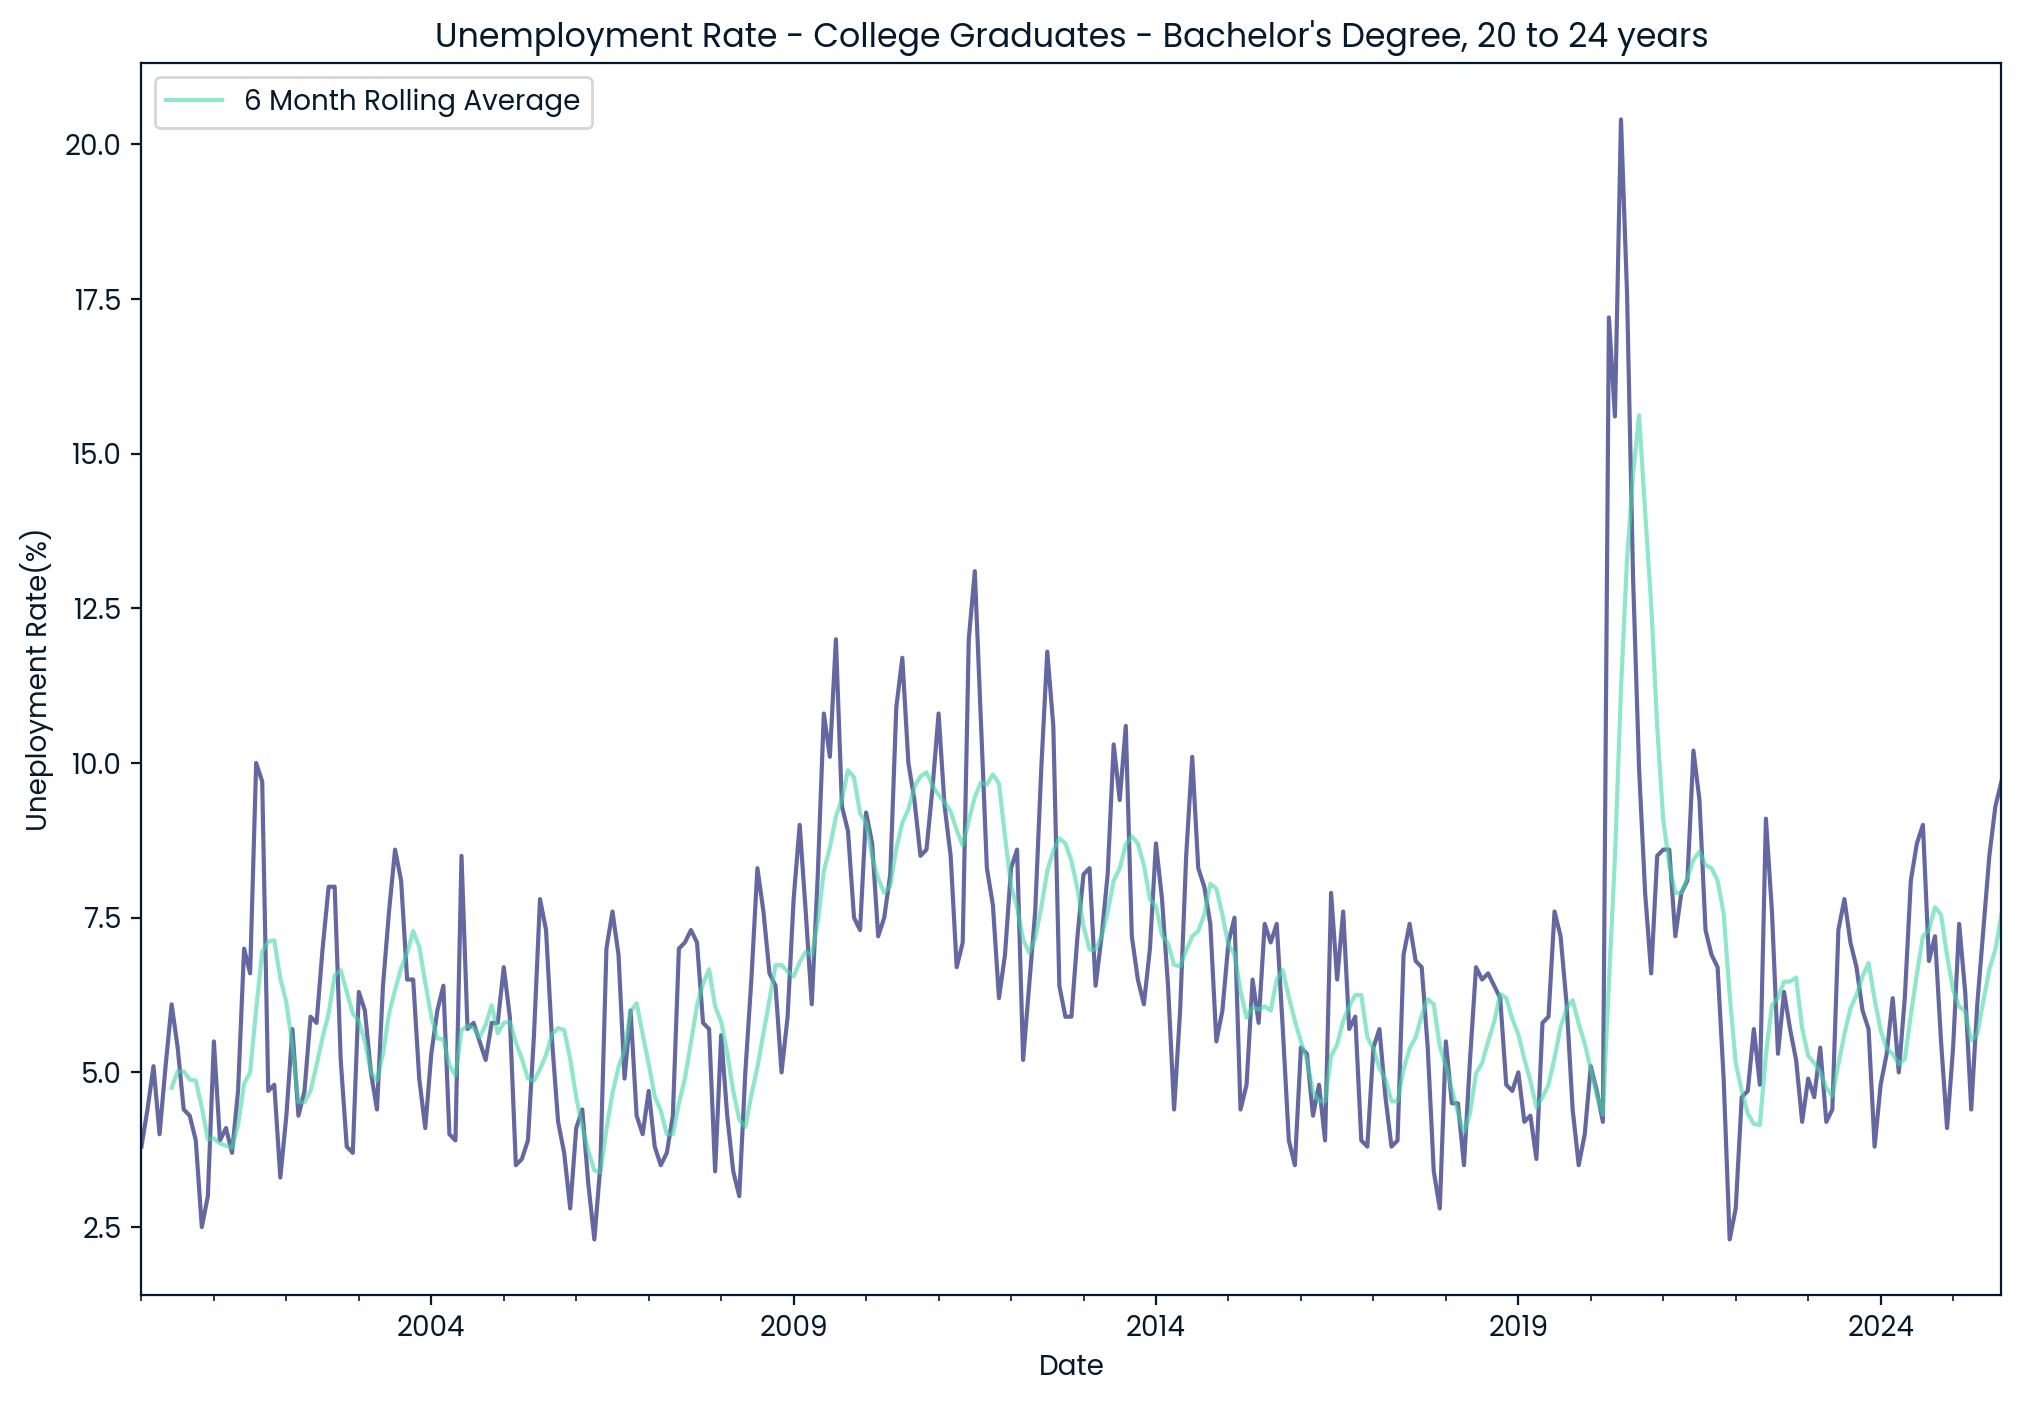

In [28]:
plt.figure(figsize = (12, 8))
unemp_college_updated.plot()
unemp_college_updated.rolling(window=6).mean().plot(label="6 Month Rolling Average", alpha=0.6)

plt.xlabel("Date")
plt.ylabel("Uneployment Rate(%)")
plt.title("Unemployment Rate - College Graduates - Bachelor's Degree, 20 to 24 years")
plt.legend()

plt.show()

In [29]:
print(unemp_college_updated)

2000-01-01    3.8
2000-02-01    4.4
2000-03-01    5.1
2000-04-01    4.0
2000-05-01    5.1
             ... 
2025-05-01    6.1
2025-06-01    7.3
2025-07-01    8.5
2025-08-01    9.3
2025-09-01    9.7
Length: 309, dtype: float64


In [30]:
# -- Check newest entry
unemp_college_updated[-1]

np.float64(9.7)

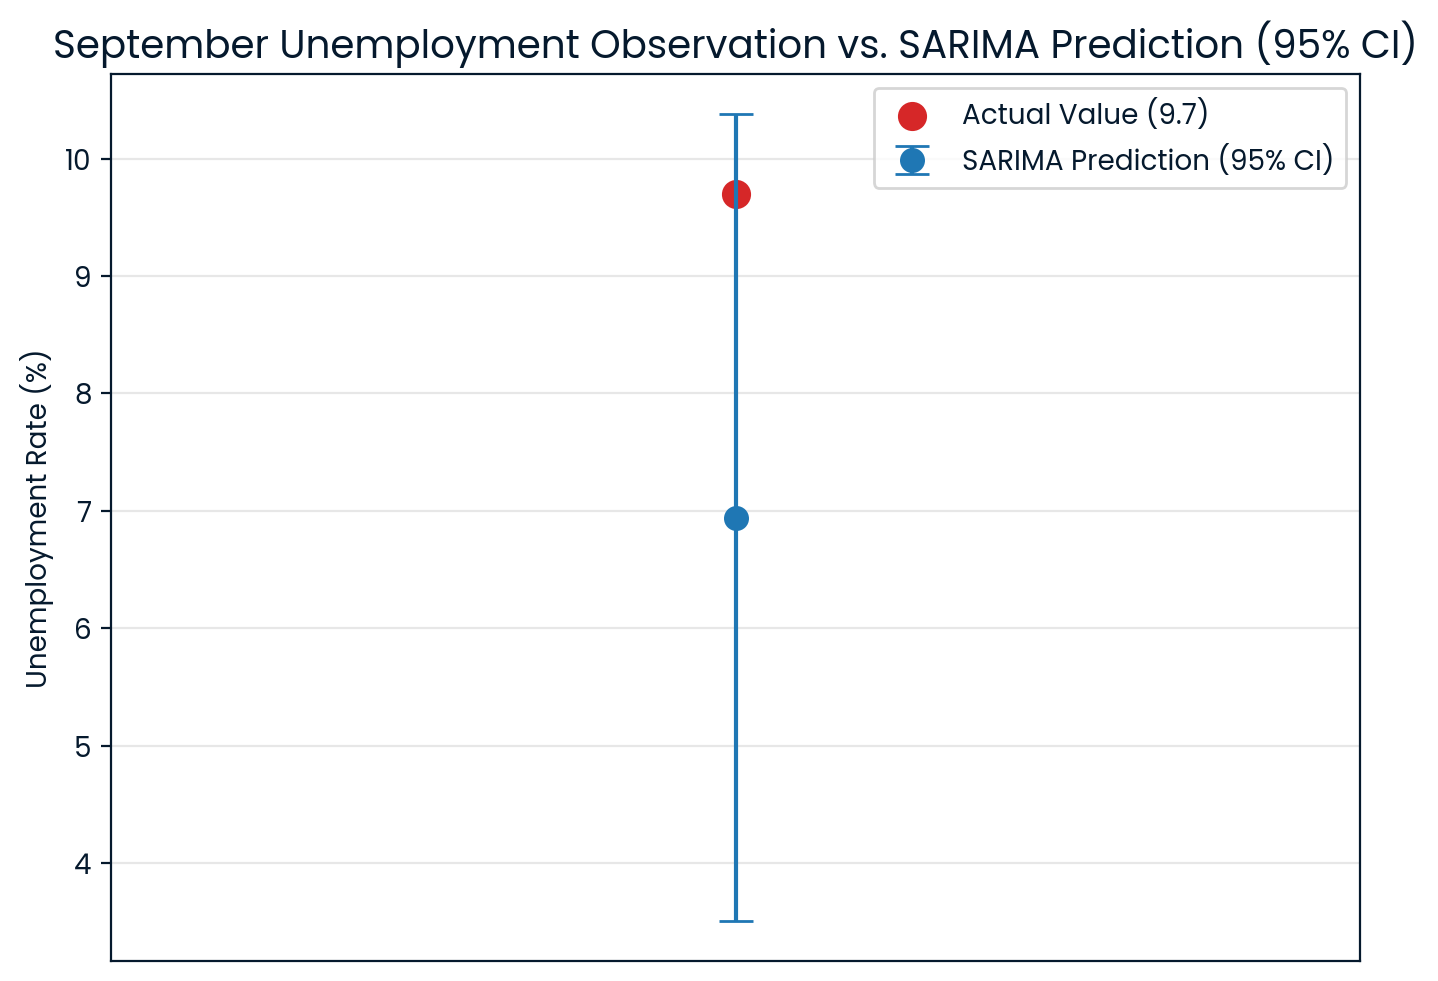

In [31]:
# -- Compare to our prediction for that month. 
# -- SARIMA Models Predicted Mean was: 6.94
# -- SARIMA Models Lower Bound was: 3.51
# -- SARIMA Models Upper Bound was: 10.38

actual = float(unemp_college_updated[-1])   # newest observation
pred_mean = 6.94                            # SARIMA predicted mean
ci_low  = 3.51                              # SARIMA lower CI
ci_high = 10.38                             # SARIMA upper CI


# --- Prepare data ---
x = [0]                                # single point
pred_err_low  = pred_mean - ci_low
pred_err_high = ci_high - pred_mean

# --- Plot ---
plt.figure(figsize=(7, 5))
plt.errorbar(
    x, 
    [pred_mean],
    yerr=[[pred_err_low], [pred_err_high]],
    fmt='o',
    capsize=6,
    markersize=8,
    label="SARIMA Prediction (95% CI)",
    color="tab:blue"
)

# Add actual observation
plt.scatter(
    x,
    [actual],
    color="tab:red",
    s=90,
    label=f"Actual Value ({actual})"
)

# --- Beautify ---
plt.title("September Unemployment Observation vs. SARIMA Prediction (95% CI)", fontsize=14)
plt.ylabel("Unemployment Rate (%)")
plt.xticks([])  # no x-axis categories
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

WOW, unemployment is going up. Lets see how many months it typically goes up

📈 Longest increase streak length: 6 months
📍 Number of tied streaks: 2

---- Streak #1 ----
Start: 2007-03-01
End:   2007-08-01
            value  change  increase
2007-03-01    3.5    -0.3     False
2007-04-01    3.7     0.2      True
2007-05-01    4.3     0.6      True
2007-06-01    7.0     2.7      True
2007-07-01    7.1     0.1      True
2007-08-01    7.3     0.2      True

---- Streak #2 ----
Start: 2025-04-01
End:   2025-09-01
            value  change  increase
2025-04-01    4.4    -1.9     False
2025-05-01    6.1     1.7      True
2025-06-01    7.3     1.2      True
2025-07-01    8.5     1.2      True
2025-08-01    9.3     0.8      True
2025-09-01    9.7     0.4      True



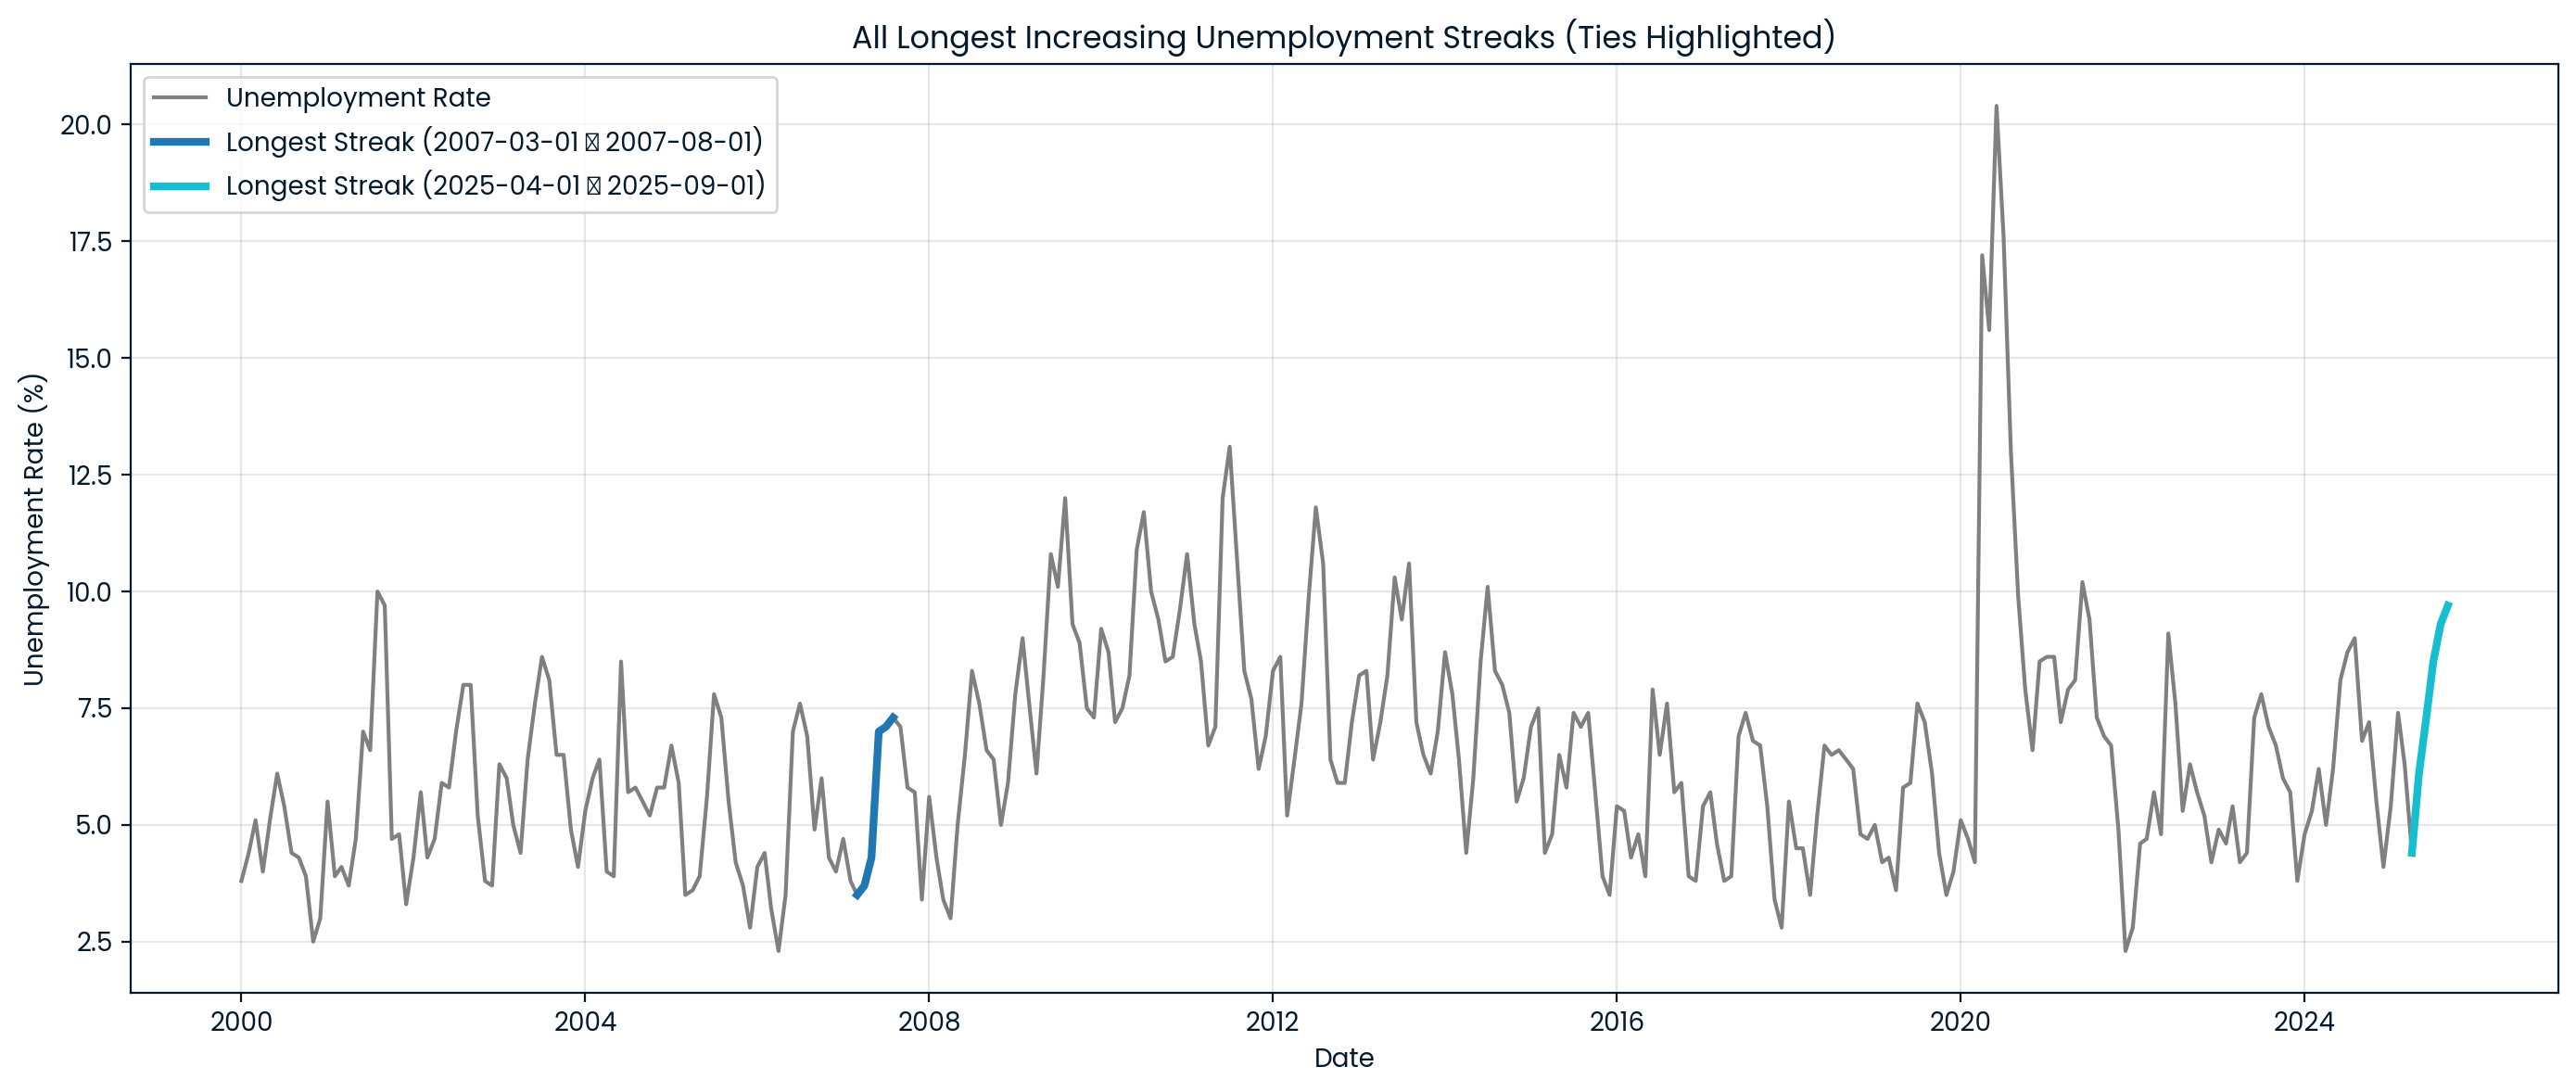

In [32]:
s = unemp_college_updated.copy().sort_index()

df = pd.DataFrame({"value": s})
df["change"] = df["value"].diff()
df["increase"] = df["change"] > 0

# ------------------------------------------------------------------
# 1. Build all streak segments (month-based, not transition-based)
# ------------------------------------------------------------------
streaks = []
current = []

for i in range(len(df)):

    if df["increase"].iloc[i]:
        # include both start (i-1) and end (i)
        if not current:
            current = [i-1, i]    # start new segment
        else:
            current.append(i)     # continue streak
    else:
        if current:
            streaks.append(current)
        current = []

# Append final streak if it ended at the last row
if current:
    streaks.append(current)

# Convert streaks to dictionary with actual dates + values
streak_info = []
for seg in streaks:
    idx = df.index[seg]
    vals = df.iloc[seg]["value"].values
    streak_info.append({
        "start": idx[0],
        "end": idx[-1],
        "length_months": len(seg),
        "index_positions": seg,
        "values": vals
    })

# ------------------------------------------------------------------
# 2. Find longest streak length
# ------------------------------------------------------------------
if streak_info:
    max_len = max(s["length_months"] for s in streak_info)
else:
    max_len = 0

# All tied streaks
longest_streaks = [s for s in streak_info if s["length_months"] == max_len]

# ------------------------------------------------------------------
# 3. Print results
# ------------------------------------------------------------------
print(f"📈 Longest increase streak length: {max_len} months")
print(f"📍 Number of tied streaks: {len(longest_streaks)}\n")

for i, st in enumerate(longest_streaks, 1):
    print(f"---- Streak #{i} ----")
    print(f"Start: {st['start'].date()}")
    print(f"End:   {st['end'].date()}")
    print(df.loc[st["start"]:st["end"]])
    print()

# ------------------------------------------------------------------
# 4. Plot: highlight ALL longest streaks
# ------------------------------------------------------------------
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["value"], color='gray', label="Unemployment Rate")

colors = plt.cm.tab10(np.linspace(0, 1, len(longest_streaks)))

for color, st in zip(colors, longest_streaks):
    highlight = df.loc[st["start"]:st["end"]]
    plt.plot(
        highlight.index,
        highlight["value"],
        linewidth=3,
        color=color,
        label=f"Longest Streak ({st['start'].date()} → {st['end'].date()})"
    )

plt.title("All Longest Increasing Unemployment Streaks (Ties Highlighted)")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [34]:
# -- How many times has September Unemployment Surpassed August
df = (
    unemp_college_updated
    .to_frame("Rate")
    .assign(Year=lambda x: x.index.year, Month=lambda x: x.index.month)
)

aug = df[df["Month"] == 8].set_index("Year")["Rate"]
sep = df[df["Month"] == 9].set_index("Year")["Rate"]

# Combine into one DataFrame
comparison = pd.DataFrame({
    "August": aug,
    "September": sep
})

# Add comparison column
comparison["Sep_gt_Aug"] = comparison["September"] > comparison["August"]

print(comparison)

      August  September  Sep_gt_Aug
Year                               
2000     4.4        4.3       False
2001    10.0        9.7       False
2002     8.0        8.0       False
2003     8.1        6.5       False
2004     5.8        5.5       False
2005     7.3        5.5       False
2006     6.9        4.9       False
2007     7.3        7.1       False
2008     7.6        6.6       False
2009    12.0        9.3       False
2010    10.0        9.4       False
2011    10.7        8.3       False
2012    10.6        6.4       False
2013    10.6        7.2       False
2014     8.3        8.0       False
2015     7.1        7.4        True
2016     7.6        5.7       False
2017     6.8        6.7       False
2018     6.6        6.4       False
2019     7.2        6.1       False
2020    13.0        9.9       False
2021     7.3        6.9       False
2022     5.3        6.3        True
2023     7.1        6.7       False
2024     9.0        6.8       False
2025     9.3        9.7     

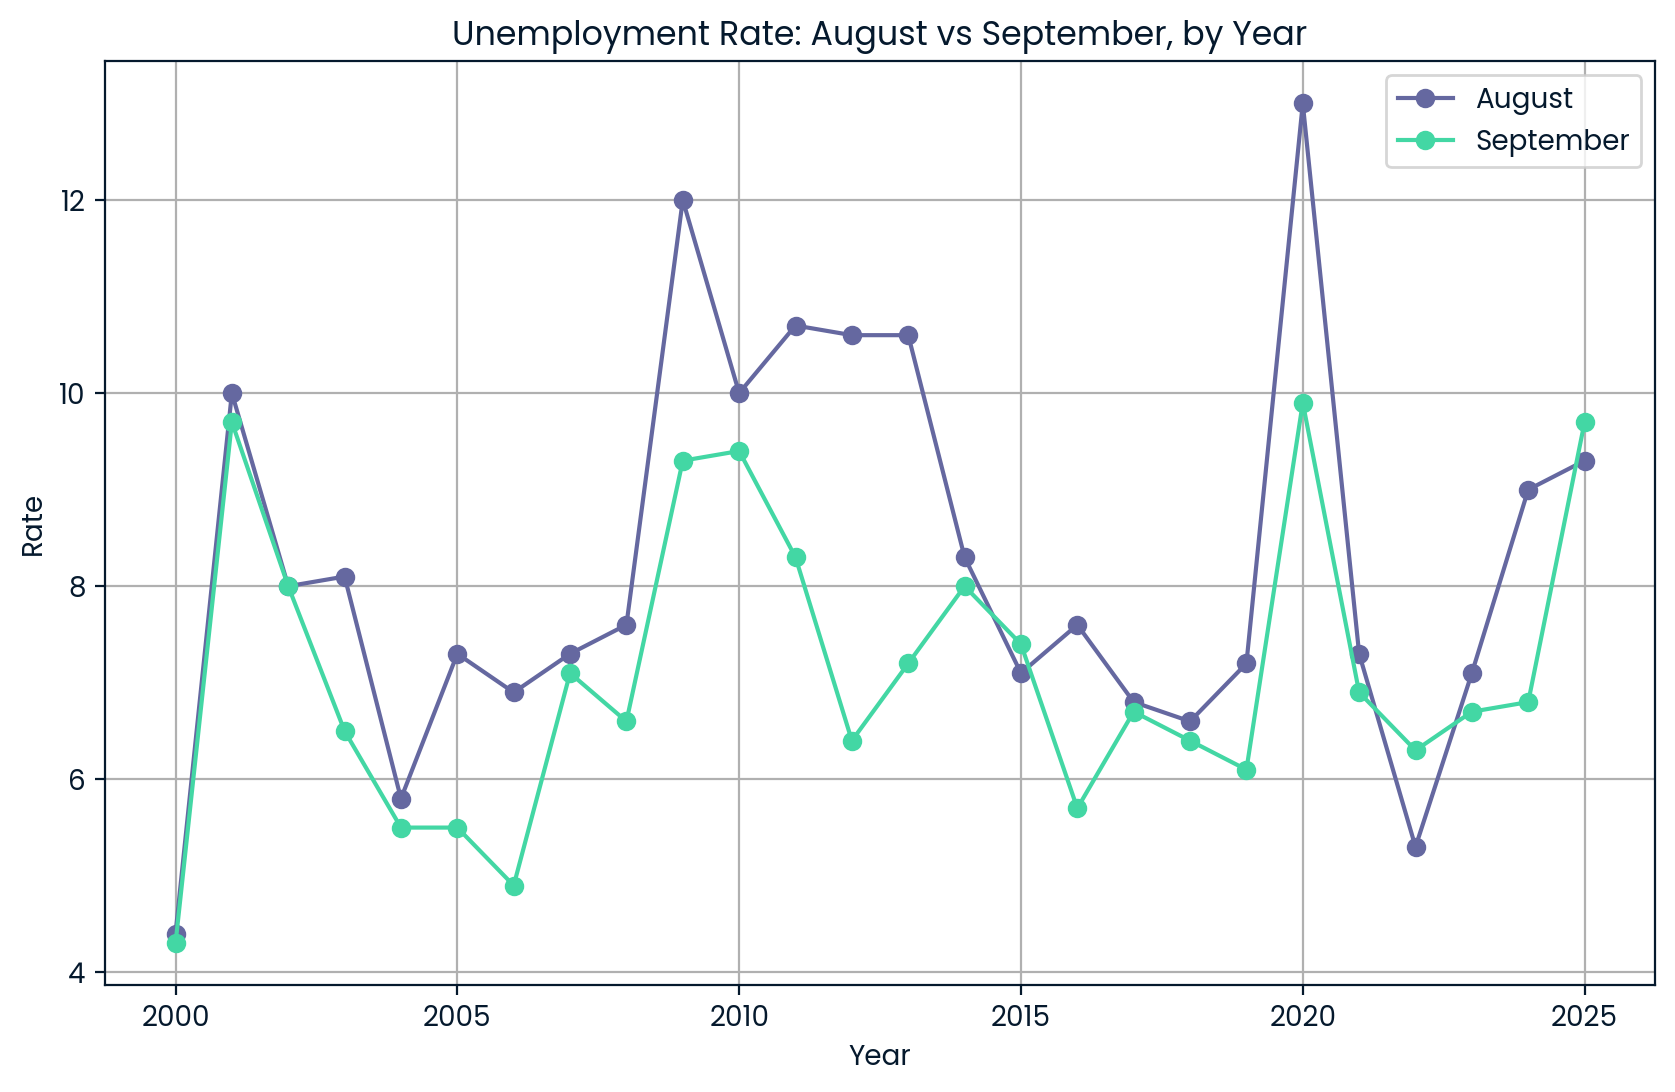

In [35]:
# -- We see from the df and plot that unemploymentt for new grads in the Month of September has only ever exceeded the August month 3 times before
plt.figure(figsize=(10,6))
plt.plot(comparison.index, comparison["August"], marker="o", label="August")
plt.plot(comparison.index, comparison["September"], marker="o", label="September")

plt.title("Unemployment Rate: August vs September, by Year")
plt.xlabel("Year")
plt.ylabel("Rate")
plt.legend()
plt.grid(True)
plt.show()